# ShopSphere – Customer Retention & Cohort Analysis  

### Customer Behaviour Analytics & Retention Strategy  

**Author:** Oghenevurie Lauretta  
**Email:** laureldebelle@gmail.com  

---

## Skills Demonstrated  

- Python (Pandas, NumPy)  
- Exploratory Data Analysis (EDA)  
- Feature Engineering & Data Preparation  
- Cohort Analysis & Retention Modelling  
- RFM Segmentation  
- Data Visualisation (Matplotlib, Seaborn)  
- Business Insight Translation & Decision Support  

---

##  Project Sections  

1. Business Background  
2. Project Objectives & Key Business Questions  
3. Dataset Overview     
4. Exploratory Data Analysis (EDA)  
5. RFM Feature Engineering
- RFM Metrics
- RFM Distribution Analysis
- RFM Scoring Insights
- Customer Segmentation
6. Cohort Retention Analysis  
7. Strategic Recommedations
8. Conlusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **1. BUSINESS BACKGROUND** #

ShopSphere operates within a competitive e-commerce environment where understanding customer behaviour is essential for sustaining growth. While transaction volumes remain steady, there is limited visibility into customer engagement, repeat purchasing patterns, and retention performance.

This analysis aims to bridge that gap by leveraging transactional data to identify key behavioural trends, segment customers, and assess retention across cohorts. The insights generated will support more targeted marketing strategies, improved customer retention, and enhanced overall business performance.

# **2. PROJECT OBJECTIVES AND KEY BUSINESS QUESTIONS**


Objectives

This analysis aims to provide a structured understanding of customer behaviour to support more effective retention and value optimisation strategies. The focus is on identifying patterns in engagement, quantifying customer value, and uncovering opportunities to improve long-term customer relationships.

Key Business Questions

- To what extent is the business successfully retaining customers beyond their initial purchase?
- Which customer segments drive the highest value, and how can they be prioritised?
- Where in the customer lifecycle does disengagement occur most prominently?
- Are there variations in retention performance across different acquisition cohorts?
- What targeted actions can be implemented to strengthen retention and maximise customer lifetime value?

# **3. DATASET OVERVIEW**

The analysis is based on a transactional dataset capturing customer purchase activity within an e-commerce environment. Each record represents an individual transaction, including information on products purchased, quantities, pricing, transaction dates, and customer identifiers.

The dataset provides a comprehensive view of customer behaviour over time, enabling analysis of purchasing patterns, revenue contribution, and engagement trends. Its structure supports both transaction-level analysis and aggregation into customer-level insights, forming the foundation for cohort analysis and RFM-based segmentation.

In [2]:
df=pd.read_csv('/content/drive/MyDrive/Copy of ShopSphere_Dataset.csv')

In [3]:
df.head()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
0,400000,2024-01-21 03:01:47,10000,40565,Groceries,31,5.56,United Kingdom
1,400000,2024-01-21 03:01:47,10000,40048,Fashion,14,34.86,United Kingdom
2,400000,2024-01-21 03:01:47,10000,40149,Electronics,48,149.66,United States
3,400000,2024-01-21 03:01:47,10000,40514,Sports & Outdoors,7,38.30,United States
4,400000,2024-01-21 03:01:47,10000,40607,Groceries,4,7.66,United States


In [4]:
df.tail()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
385309,420989,2024-10-11 09:01:10,14371,40623,Groceries,35,20.17,United States
385310,420989,2024-10-11 09:01:10,14371,40504,Sports & Outdoors,54,37.31,United States
385311,420989,2024-10-11 09:01:10,14371,40189,Home & Living,83,18.24,United States
385312,420989,2024-10-11 09:01:10,14371,40299,Beauty & Wellness,100,39.94,United States
385313,420989,2024-10-11 09:01:10,14371,40029,Fashion,86,27.04,United States


In [5]:
df.shape

(385314, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385314 entries, 0 to 385313
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    385314 non-null  int64  
 1   InvoiceDate  385314 non-null  object 
 2   CustomerID   385314 non-null  int64  
 3   StockCode    385314 non-null  int64  
 4   Description  385314 non-null  object 
 5   Quantity     385314 non-null  int64  
 6   UnitPrice    385314 non-null  float64
 7   Country      385314 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 23.5+ MB


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
InvoiceDate,0
CustomerID,0
StockCode,0
Description,0
Quantity,0
UnitPrice,0
Country,0


In [8]:
df.duplicated().sum()

np.int64(0)

CLEANING DECISION: The dataset was assessed for quality and found to be complete, with no missing values or duplicate records. As such, minimal data cleaning was required prior to analysis

# **4. Exploratory Data Analysis (EDA)**

Initial exploratory analysis was conducted to understand customer purchasing behaviour and identify key patterns in engagement. The focus was placed on purchase frequency and revenue distribution to assess whether customer activity is broadly distributed or concentrated among a smaller segment of users.

These insights provide early indicators of customer retention challenges and support further cohort-based analysis.

<Axes: >

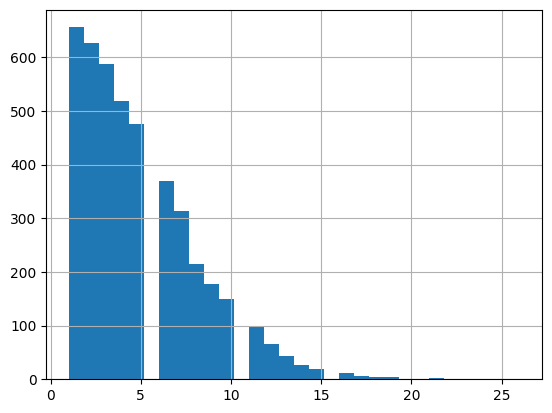

In [17]:
purchase_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()

purchase_freq.hist(bins=30)

**Purchase Frequency Insights**

The distribution of purchase frequency is heavily right-skewed, indicating that the majority of customers make only a small number of purchases, typically between one and five transactions.

A sharp decline is observed as purchase frequency increases, with only a limited number of customers demonstrating higher repeat purchasing behaviour. This suggests that most customers engage with the platform on a one-time or low-frequency basis, while a smaller segment contributes to repeat activity.

These findings reinforce the presence of early-stage churn identified in the cohort analysis, highlighting a strong dependency on a relatively small group of repeat customers.

**Revenue Distribution Analysis**

To further understand customer value contribution, revenue distribution was analysed to assess whether overall revenue is evenly distributed across customers or driven by a smaller subset of high-value purchasers.

<Axes: >

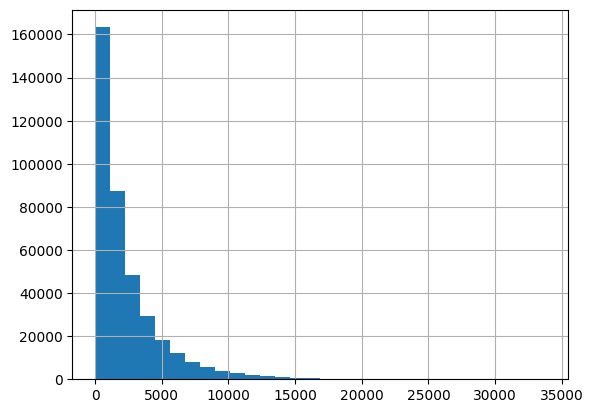

In [18]:
df['Revenue'].hist(bins=30)

**Revenue Distribution Insights**

The revenue distribution is highly right-skewed, indicating that the majority of transactions generate relatively low monetary value, while a small proportion of transactions contribute disproportionately high revenue.

This pattern suggests that overall revenue performance is driven by a limited segment of high-value customers or large transactions, rather than broad-based customer spending.

From a strategic perspective, this highlights an opportunity to both:
- Increase the average transaction value among low-spending customers, and  
- Identify and retain high-value customers who contribute significantly to total revenue.

This imbalance reinforces the importance of targeted customer segmentation and personalized engagement strategies to maximise customer lifetime value.

# **5. RFM FEATURE ENGINEERING**


To better understand customer behaviour and support segmentation, RFM (Recency, Frequency, Monetary) metrics were developed.

These features provide a structured view of:
- How recently customers made a purchase (Recency),
- How often they purchase (Frequency),
- How much value they contribute (Monetary).

This enables more targeted analysis of customer engagement and supports downstream clustering and retention strategies.

In [19]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [9]:
# Convert to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Month-Year for cohort analysis
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Create revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [10]:
df.head()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,InvoiceMonth,Revenue
0,400000,2024-01-21 03:01:47,10000,40565,Groceries,31,5.56,United Kingdom,2024-01,172.36
1,400000,2024-01-21 03:01:47,10000,40048,Fashion,14,34.86,United Kingdom,2024-01,488.04
2,400000,2024-01-21 03:01:47,10000,40149,Electronics,48,149.66,United States,2024-01,7183.68
3,400000,2024-01-21 03:01:47,10000,40514,Sports & Outdoors,7,38.30,United States,2024-01,268.10
4,400000,2024-01-21 03:01:47,10000,40607,Groceries,4,7.66,United States,2024-01,30.64


**RFM Metrics Calculation**

To quantify customer engagement and value, RFM metrics were calculated at the customer level.

- **Recency** measures how recently a customer made a purchase.
- **Frequency** captures how often a customer transacts.
- **Monetary** reflects the total revenue contributed by each customer.

These metrics form the foundation for customer segmentation and enable identification of high-value and at-risk customer groups.

In [20]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [21]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,10000,140,5,242993.87
1,10001,86,1,20841.75
2,10002,23,6,254693.19
3,10003,89,2,115314.08
4,10004,100,7,305794.35


**RFM Metrics — Initial Observations**

The RFM table provides a consolidated customer-level view of purchasing behaviour across recency, frequency, and monetary value.

Initial observations indicate significant variability across customers:
- **Recency** ranges widely, suggesting a mix of recently active and dormant customers.
- **Frequency** remains relatively low for some customers, highlighting a large proportion of one-time or infrequent buyers.
- **Monetary value** varies substantially, with certain customers contributing disproportionately high revenue.

This variation highlights the presence of distinct customer segments, including high-value repeat customers, occasional buyers, and potentially at-risk or inactive customers.

These insights provide a strong foundation for targeted segmentation and retention strategies, particularly in identifying high-value customers and those requiring re-engagement.

**RFM Distribution Analysis**

To better understand the distribution of customer behaviour, histograms were generated for Recency, Frequency, and Monetary metrics.

This step helps identify skewness, outliers, and natural groupings within the data, which is critical for effective segmentation and modelling.

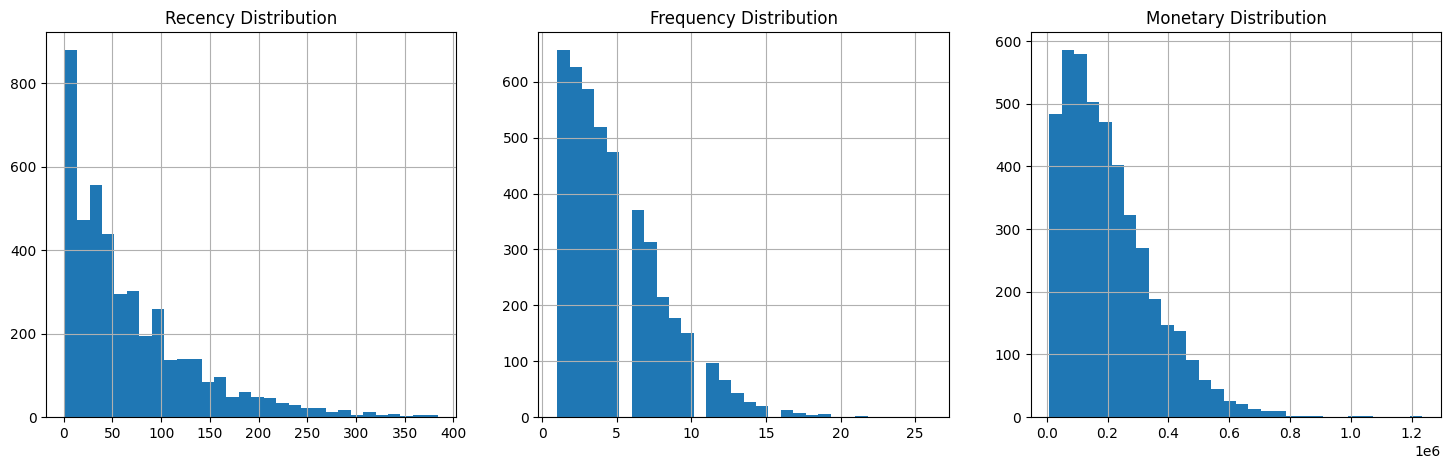

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

rfm['Recency'].hist(ax=axes[0], bins=30)
axes[0].set_title('Recency Distribution')

rfm['Frequency'].hist(ax=axes[1], bins=30)
axes[1].set_title('Frequency Distribution')

rfm['Monetary'].hist(ax=axes[2], bins=30)
axes[2].set_title('Monetary Distribution')

plt.show()

### RFM Distribution Insights

The distributions of Recency, Frequency, and Monetary metrics exhibit strong right-skewness, indicating that customer behaviour is not evenly distributed across the population.

- **Recency**: A large proportion of customers have made purchases recently, while a smaller segment shows significantly higher recency values, suggesting inactive or at-risk customers.
  
- **Frequency**: Most customers transact infrequently, with a steep drop-off as purchase frequency increases. This indicates that repeat purchasing behaviour is concentrated within a relatively small group of customers.

- **Monetary**: Revenue contribution is highly skewed, with the majority of customers generating low to moderate revenue, while a small subset contributes disproportionately high value.

Overall, these distributions confirm the presence of distinct customer segments, including low-engagement customers, moderately active users, and high-value loyal customers.

From a strategic standpoint, this reinforces the need for segmentation approaches that differentiate customer groups based on behavioural and value-based characteristics.

**RFM Scoring**

To enable structured customer segmentation, RFM values were transformed into quantile-based scores.

Each customer was assigned a score from 1 to 5 for Recency, Frequency, and Monetary metrics based on their relative position within the dataset.

This standardisation allows for consistent comparison across customers and supports the identification of key segments such as high-value, loyal, and at-risk customers.

In [23]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [24]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,10000,140,5,242993.87,1,3,4,134
1,10001,86,1,20841.75,2,1,1,211
2,10002,23,6,254693.19,4,4,4,444
3,10003,89,2,115314.08,2,1,2,212
4,10004,100,7,305794.35,2,4,4,244


### RFM Scoring Insights

The RFM scoring framework standardises customer behaviour into comparable segments by assigning scores across Recency, Frequency, and Monetary dimensions.

- Customers with **higher R scores** represent more recently active users.
- Higher **F scores** indicate stronger purchasing frequency and engagement.
- Higher **M scores** reflect greater revenue contribution.

The combined RFM score provides a concise representation of customer value and engagement level.

Initial observations highlight clear differentiation across customers:
- Some customers demonstrate strong performance across all three dimensions (e.g., high RFM scores such as 444), indicating high-value, engaged customers.
- Others exhibit low frequency and monetary values despite moderate recency, suggesting low engagement or one-time buyers.
- A segment of customers shows high recency values (low R scores), indicating potential inactivity or churn risk.

This structured scoring approach enables the identification of actionable customer segments and supports targeted retention and growth strategies.

**Customer Segmentation**

To translate RFM scores into actionable insights, customers were grouped into meaningful behavioural segments.

These segments enable the business to identify high-value customers, retain loyal users and re-engage at-risk customers through targeted strategies.

In [25]:
def segment_customer(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'Potential Loyalists'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [26]:
rfm['Segment'].value_counts()

,count
Segment,
Others,1395
Loyal Customers,1339
At Risk,833
Potential Loyalists,571
Champions,234


### Customer Segmentation Insights

The RFM-based segmentation reveals a diverse customer base with clear distinctions in engagement, loyalty, and revenue contribution.

- The largest segment, **"Others"**, suggests a broad base of moderately engaged or undefined customers who may require further targeting to increase value.
- A substantial proportion of **"Loyal Customers"** indicates a strong core of repeat buyers who contribute consistently to revenue.
- The presence of a significant **"At Risk"** segment highlights customers with declining engagement, representing a critical opportunity for reactivation strategies.
- **"Potential Loyalists"** represent an emerging segment with recent activity but lower frequency, offering strong growth potential if nurtured effectively.
- A smaller but highly valuable group of **"Champions"** reflects top-performing customers who are both highly engaged and high-spending.

Overall, the segmentation demonstrates that while the business has a solid base of loyal customers, there is a notable opportunity to improve retention and convert moderate or at-risk customers into higher-value segments.

# **6. COHORT RETENTION ANALYSIS**

Cohort analysis was conducted to evaluate customer retention over time by grouping customers based on their initial purchase period and tracking their subsequent engagement across future intervals.

This approach provides a longitudinal view of customer behaviour, enabling the identification of retention patterns, early-stage drop-off points, and variations in performance across different cohorts. By examining how customer engagement evolves, the analysis highlights critical stages in the customer lifecycle where retention efforts can be most effectively targeted.

The insights derived from this analysis form a key foundation for understanding customer churn dynamics and informing data-driven retention strategies.

In [11]:
# Create Cohort Month (first purchase month per customer)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# Cohort Index

In [12]:
# Extract year and month
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonthNum'] = df['InvoiceDate'].dt.month

df['CohortYear'] = df['CohortMonth'].dt.year
df['CohortMonthNum'] = df['CohortMonth'].dt.month

# Create Cohort Index
df['CohortIndex'] = (
    (df['InvoiceYear'] - df['CohortYear']) * 12 +
    (df['InvoiceMonthNum'] - df['CohortMonthNum']) + 1
)

In [13]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

In [14]:
cohort_pivot = cohort_data.pivot(index='CohortMonth',
                                columns='CohortIndex',
                                values='CustomerID')

In [15]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

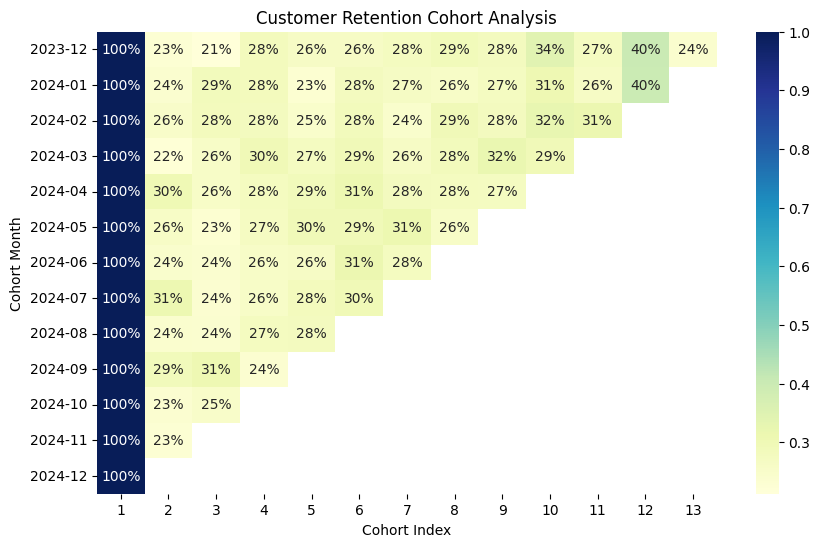

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title("Customer Retention Cohort Analysis")
plt.ylabel("Cohort Month")
plt.xlabel("Cohort Index")
plt.show()

### Cohort Retention Analysis — Key Insights

The cohort retention heatmap reveals a consistent pattern of declining customer retention across all acquisition cohorts over time.

Across nearly all cohorts, retention drops significantly after the first period, with the most pronounced decline occurring between the first and second intervals. This indicates that while initial customer acquisition is effective, early-stage retention remains a critical challenge.

Following the initial drop, retention stabilises at lower levels, typically within the 25–35% range, suggesting the presence of a core group of repeat customers who continue to engage over time.

Some cohorts exhibit relatively stronger retention in later periods, which may reflect variations in customer acquisition quality, seasonality, or promotional effectiveness. However, no cohort demonstrates sustained high retention across extended periods.

From a strategic perspective, these findings highlight:
- A **strong need to improve early customer retention**, particularly immediately after the first purchase.
- An opportunity to **identify and replicate high-performing cohorts**.
- The importance of **targeted onboarding and post-purchase engagement strategies** to reduce early churn.

Overall, the analysis indicates that improving retention in the initial customer lifecycle stages could significantly enhance long-term customer value and overall profitability.

# **7. Strategic Recommendations**

Based on the customer segmentation analysis, the following actions are recommended:

- **Retain High-Value Customers**: Prioritise "Champions" and "Loyal Customers" through loyalty programs, exclusive offers, and personalised engagement to maximise lifetime value.

- **Re-engage At-Risk Customers**: Implement targeted reactivation campaigns such as discounts, reminders, or personalised recommendations to reduce churn and recover lost revenue.

- **Nurture Potential Loyalists**: Encourage repeat purchases through onboarding incentives, follow-up campaigns, and tailored promotions to convert this segment into loyal customers.

- **Activate the “Others” Segment**: Use targeted marketing strategies and behavioural insights to better understand and engage this broad customer group.

- **Leverage Data-Driven Decision Making**: Continuously monitor RFM trends and cohort behaviour to refine retention strategies and optimise marketing spend.

# **8. Conclusion**

This analysis demonstrates that customer behaviour is highly uneven, with a small proportion of customers driving a significant share of revenue.

By leveraging RFM segmentation and cohort insights, the business can move towards more targeted, data-driven strategies that enhance customer retention, increase engagement, and maximise long-term profitability.